### Noisy Data: Trial Run

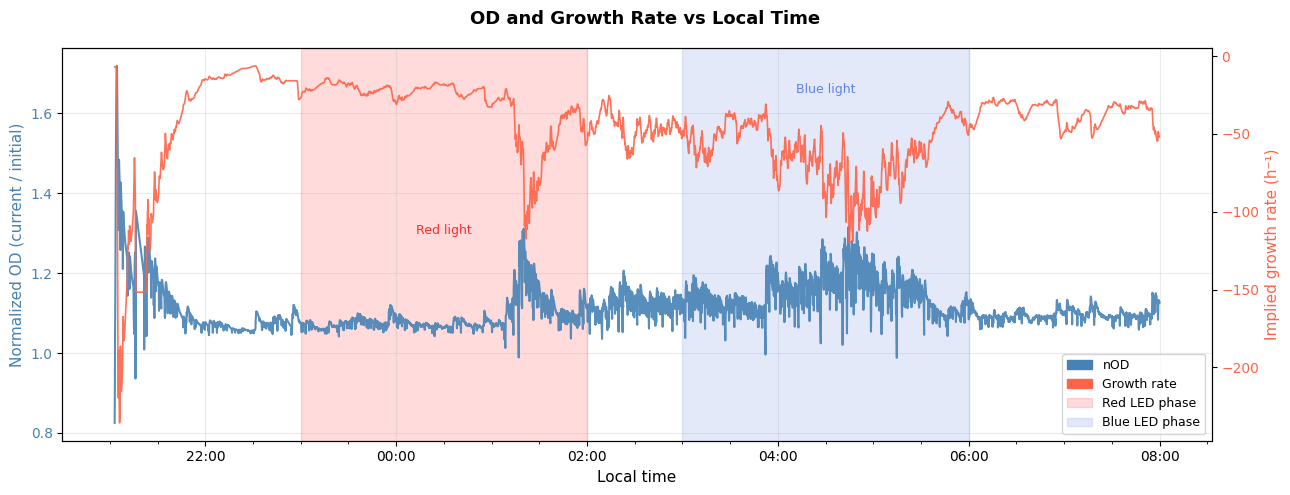

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

FILE_NOD = "./data/01st June (LED trial run)/od_readings_filtered-experiment_May-all_units-20260603000731.csv"
FILE_GR  = "./data/01st June (LED trial run)/growth_rates-experiment_May-all_units-20260603000731.csv"

nod = pd.read_csv(FILE_NOD)
gr = pd.read_csv(FILE_GR)

for df in [nod, gr]:
    df['timestamp_localtime'] = pd.to_datetime(df['timestamp_localtime'])

nod = nod.sort_values('timestamp_localtime')
gr = gr.sort_values('timestamp_localtime')

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

l1, = ax1.plot(nod['timestamp_localtime'],
               nod['normalized_od_reading'],
               color='steelblue', lw=1.5, alpha=0.9, label='nOD')
ax1.set_ylabel('Normalized OD (current / initial)', fontsize=11, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

l2, = ax2.plot(gr['timestamp_localtime'],
               gr['rate'],
               color='tomato', lw=1.2, alpha=0.9, label='Growth rate')
ax2.set_ylabel('Implied growth rate (h⁻¹)', fontsize=11, color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

ax1.set_xlabel('Local time', fontsize=11)
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())

# ── LED phase shading ─────────────────────────────────────────────────────────
first_date = nod['timestamp_localtime'].dt.normalize().min()
red_start = first_date + pd.Timedelta(hours=23)
red_end = red_start + pd.Timedelta(hours=3)
blue_start = first_date + pd.Timedelta(days=1, hours=3)
blue_end = blue_start + pd.Timedelta(hours=3)

ax1.axvspan(red_start, red_end, color='red', alpha=0.14, label='Red LED phase')
ax1.axvspan(blue_start, blue_end, color='royalblue', alpha=0.14, label='Blue LED phase')
ax1.text(red_start + (red_end - red_start) / 2, ax1.get_ylim()[1] * 0.75,
         'Red light', color='red', fontsize=9, ha='center', va='top', alpha=0.8)
ax1.text(blue_start + (blue_end - blue_start) / 2, ax1.get_ylim()[1] * 0.95,
         'Blue light', color='royalblue', fontsize=9, ha='center', va='top', alpha=0.8)

ax1.grid(True, alpha=0.25, zorder=0)
legend_handles = [Patch(color='steelblue', label='nOD'), Patch(color='tomato', label='Growth rate'),
                  Patch(color='red', alpha=0.14, label='Red LED phase'),
                  Patch(color='royalblue', alpha=0.14, label='Blue LED phase')]
ax1.legend(handles=legend_handles, loc='lower right', fontsize=9)

fig.suptitle('OD and Growth Rate vs Local Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Experiment: Trial run - Flashing blue LED light for 3 hours

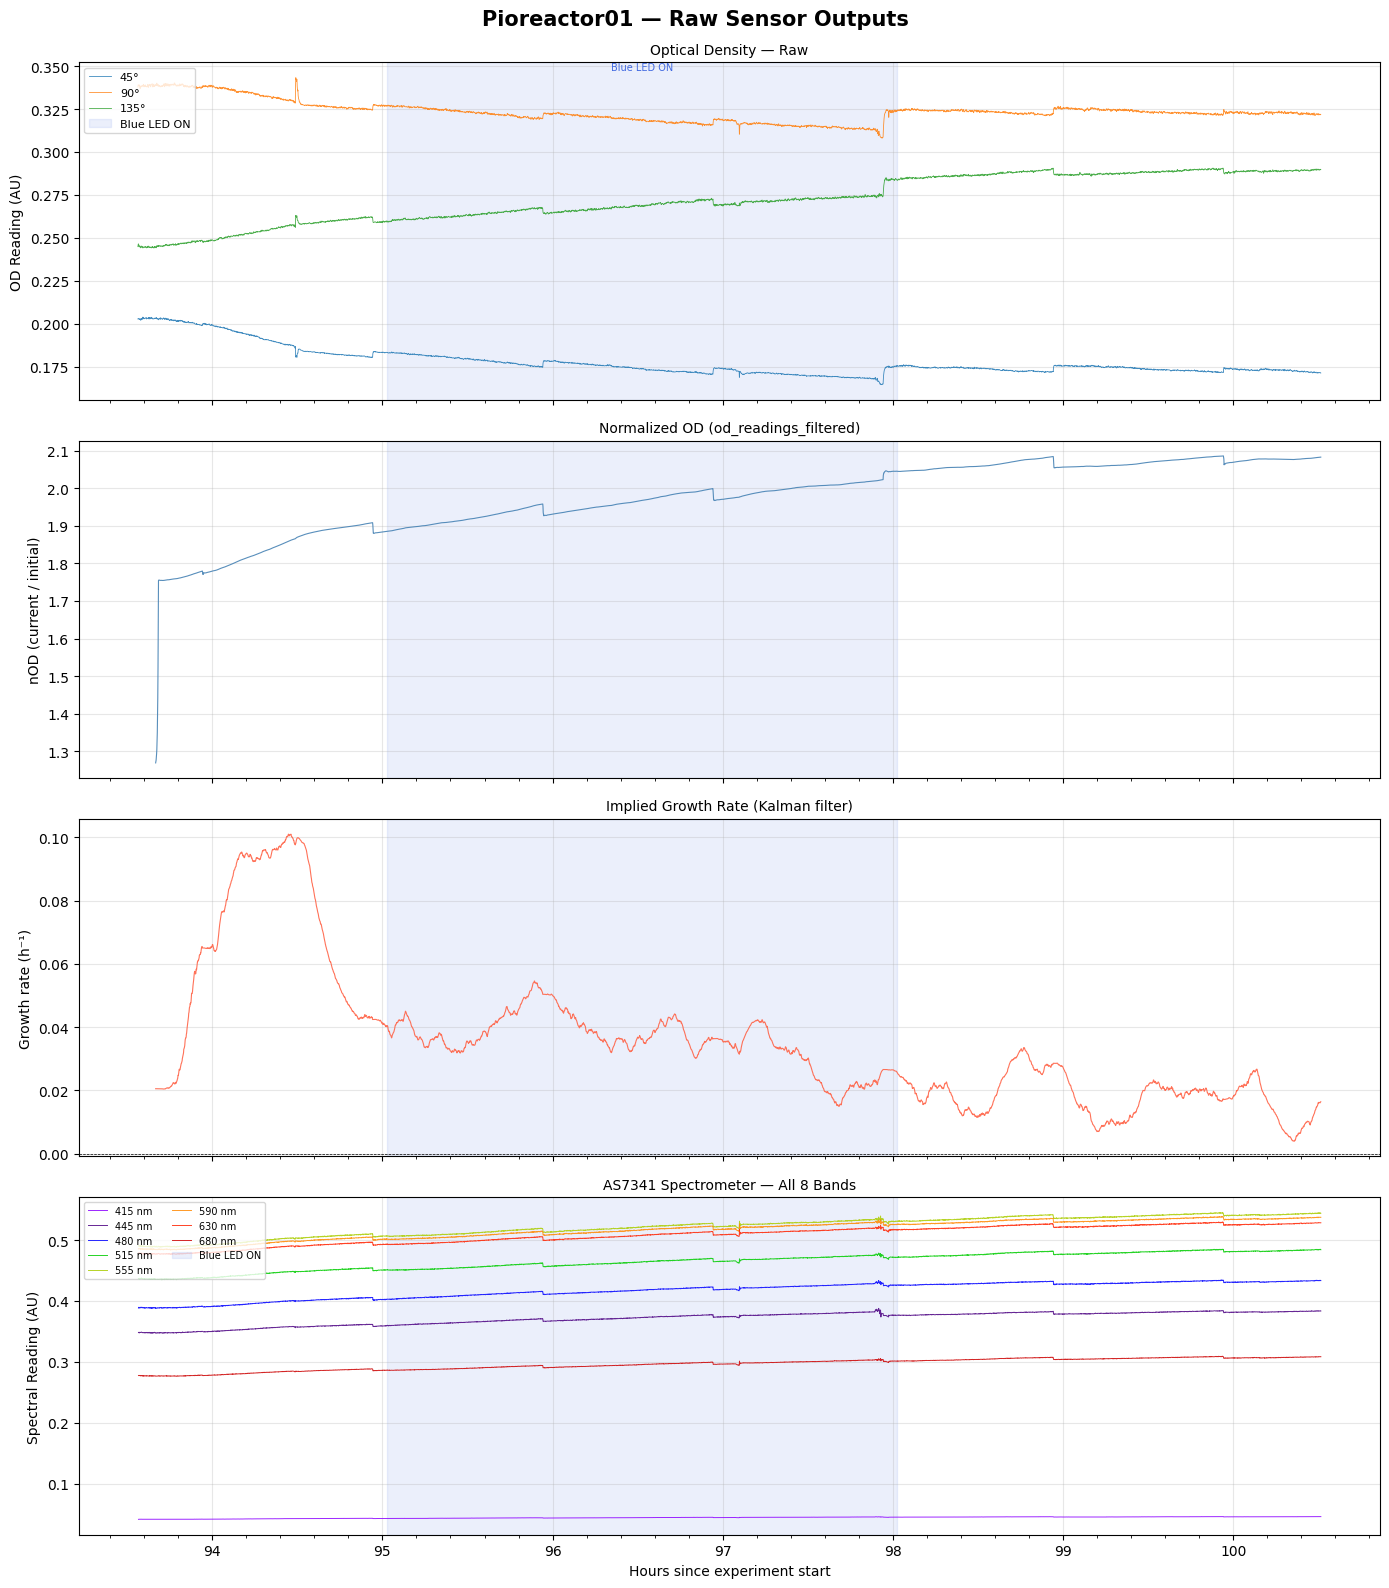

In [ ]:
# Plot: all raw sensor outputs in 4 subplots:
#   1. OD readings (all angles)
#   2. Normalized OD (od_readings_filtered)
#   3. Implied growth rate
#   4. AS7341 spectrometer (all 8 bands)
#

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── File paths ────────────────────────────────────────────────────────────────
FILE_OD         = "./data/02nd June (effect of blue LED)/od_readings-experiment_May-pioreactor01-20260602224829.csv"
FILE_NOD        = "./data/02nd June (effect of blue LED)/od_readings_filtered-experiment_May-pioreactor01-20260602224829.csv"
FILE_GR         = "./data/02nd June (effect of blue LED)/growth_rates-experiment_May-pioreactor01-20260602224829.csv"
FILE_SPEC       = "./data/02nd June (effect of blue LED)/as7341_spectrum_readings-experiment_May-pioreactor01-20260602224829.csv"
FILE_LED        = "./data/02nd June (effect of blue LED)/led_change_events-experiment_May-pioreactor01-20260602224829.csv"

# ── Load data ─────────────────────────────────────────────────────────────────
od   = pd.read_csv(FILE_OD)
nod  = pd.read_csv(FILE_NOD)
gr   = pd.read_csv(FILE_GR)
spec = pd.read_csv(FILE_SPEC)
led  = pd.read_csv(FILE_LED)

# ── LED phase boundaries (channel C = blue LED) ───────────────────────────────
# Find ON and OFF events for channel C
led_C = led[led['channel'] == 'C'].sort_values('hours_since_experiment_created')
blue_on  = led_C[led_C['intensity'] > 0]['hours_since_experiment_created'].values
blue_off = led_C[led_C['intensity'] == 0]['hours_since_experiment_created'].values

def shade_blue_phases(ax):
    """Shade blue LED ON windows on a given axis."""
    for on, off in zip(blue_on, blue_off):
        ax.axvspan(on, off, color='royalblue', alpha=0.10, label='Blue LED ON')

# ── Spectrometer: pivot so each band is a column ──────────────────────────────
spec_pivot = spec.pivot_table(
    index='hours_since_experiment_created',
    columns='band',
    values='reading',
    aggfunc='mean'
).reset_index()

BAND_COLORS = {
    415: '#8B00FF',  # violet
    445: '#4B0082',  # indigo
    480: '#0000FF',  # blue
    515: '#00CC00',  # green
    555: '#AACC00',  # yellow-green
    590: '#FF8800',  # orange
    630: '#FF2200',  # red-orange
    680: '#CC0000',  # deep red
}

# ── Figure layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
fig.suptitle('Pioreactor01 — Raw Sensor Outputs', fontsize=15, fontweight='bold', y=0.99)

# ── Subplot 1: OD readings (all angles) ───────────────────────────────────────
ax1 = axes[0]
angle_styles = {45: ('tab:blue', '-'), 90: ('tab:orange', '-'), 135: ('tab:green', '-')}
for angle, (color, ls) in angle_styles.items():
    sub = od[od['angle'] == angle].sort_values('hours_since_experiment_created')
    ax1.plot(sub['hours_since_experiment_created'], sub['od_reading'],
             color=color, lw=0.6, linestyle=ls, label=f'{angle}°', alpha=0.85)
shade_blue_phases(ax1)
ax1.set_ylabel('OD Reading (AU)', fontsize=10)
ax1.set_title('Optical Density — Raw', fontsize=10)
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

# ── Subplot 2: Normalized OD ──────────────────────────────────────────────────
ax2 = axes[1]
nod_s = nod.sort_values('hours_since_experiment_created')
ax2.plot(nod_s['hours_since_experiment_created'], nod_s['normalized_od_reading'],
         color='steelblue', lw=0.8, alpha=0.9)
shade_blue_phases(ax2)
ax2.set_ylabel('nOD (current / initial)', fontsize=10)
ax2.set_title('Normalized OD (od_readings_filtered)', fontsize=10)
ax2.grid(True, alpha=0.3)

# ── Subplot 3: Implied growth rate ────────────────────────────────────────────
ax3 = axes[2]
gr_s = gr.sort_values('hours_since_experiment_created')
ax3.plot(gr_s['hours_since_experiment_created'], gr_s['rate'],
         color='tomato', lw=0.8, alpha=0.9)
shade_blue_phases(ax3)
ax3.set_ylabel('Growth rate (h⁻¹)', fontsize=10)
ax3.set_title('Implied Growth Rate (Kalman filter)', fontsize=10)
ax3.axhline(0, color='black', lw=0.5, linestyle='--')
ax3.grid(True, alpha=0.3)

# ── Subplot 4: AS7341 spectrometer ────────────────────────────────────────────
ax4 = axes[3]
for band in sorted(spec_pivot.columns[1:]):
    ax4.plot(spec_pivot['hours_since_experiment_created'], spec_pivot[band],
             color=BAND_COLORS.get(band, 'grey'), lw=0.7,
             label=f'{band} nm', alpha=0.85)
shade_blue_phases(ax4)
ax4.set_ylabel('Spectral Reading (AU)', fontsize=10)
ax4.set_title('AS7341 Spectrometer — All 8 Bands', fontsize=10)
ax4.set_xlabel('Hours since experiment start', fontsize=10)
ax4.legend(loc='upper left', fontsize=7, ncol=2)
ax4.grid(True, alpha=0.3)

# ── Shared x-axis formatting ──────────────────────────────────────────────────
for ax in axes:
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

# Add blue LED annotation on top subplot
for on, off in zip(blue_on, blue_off):
    axes[0].annotate('Blue LED ON',
                     xy=((on + off) / 2, axes[0].get_ylim()[1]),
                     fontsize=7, color='royalblue', ha='center', va='top')

plt.tight_layout()
plt.show()


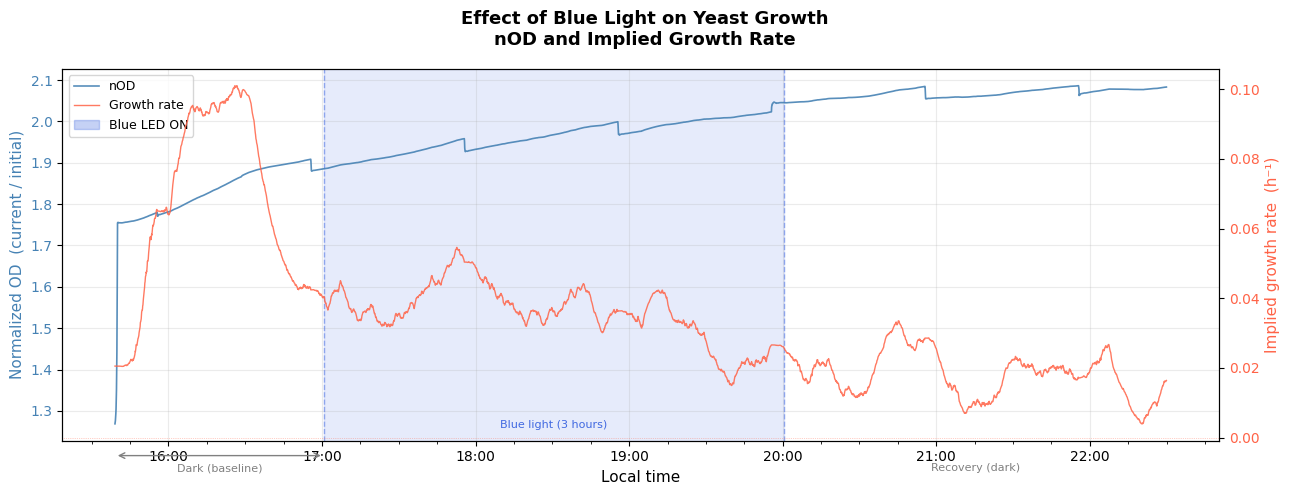

In [ ]:
# Plot: implied growth rate and normalized OD with the blue LED phase shaded in blue.

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

# ── File paths ────────────────────────────────────────────────────────────────
FILE_NOD = "./data/02nd June (effect of blue LED)/od_readings_filtered-experiment_May-pioreactor01-20260602224829.csv"
FILE_GR = "./data/02nd June (effect of blue LED)/growth_rates-experiment_May-pioreactor01-20260602224829.csv"
FILE_LED  = "./data/02nd June (effect of blue LED)/led_change_events-experiment_May-pioreactor01-20260602224829.csv"

# ── Load data ─────────────────────────────────────────────────────────────────
nod = pd.read_csv(FILE_NOD)
gr  = pd.read_csv(FILE_GR)
led = pd.read_csv(FILE_LED)

for df in [nod, gr, led]:
    df['timestamp_localtime'] = pd.to_datetime(df['timestamp_localtime'])

nod = nod.sort_values('timestamp_localtime')
gr = gr.sort_values('timestamp_localtime')
led = led.sort_values('timestamp_localtime')

# ── LED phase boundaries ──────────────────────────────────────────────────────
led_C    = led[led['channel'] == 'C'].sort_values('timestamp_localtime')
blue_on  = led_C[led_C['intensity'] > 0]['timestamp_localtime'].values
blue_off = led_C[led_C['intensity'] == 0]['timestamp_localtime'].values

# ── Figure: two y-axes sharing one x-axis ─────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

# ── Blue LED shading ──────────────────────────────────────────────────────────
for i, (on, off) in enumerate(zip(blue_on, blue_off)):
    label = 'Blue LED ON' if i == 0 else '_nolegend_'
    ax1.axvspan(on, off,
                color='royalblue', alpha=0.13, zorder=0, label=label)
    # Bracket lines at phase boundaries
    for t in [on, off]:
        ax1.axvline(t, color='royalblue', lw=1.0, linestyle='--', alpha=0.5)
    # Phase label at top
    mid = on + (off - on) / 2

# ── nOD (left axis) ───────────────────────────────────────────────────────────
l1, = ax1.plot(nod['timestamp_localtime'],
               nod['normalized_od_reading'],
               color='steelblue', lw=1.2, alpha=0.9, label='nOD', zorder=2)
ax1.set_ylabel('Normalized OD  (current / initial)', fontsize=11, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xlabel('Local time', fontsize=11)

# ── Growth rate (right axis) ──────────────────────────────────────────────────
l2, = ax2.plot(gr['timestamp_localtime'],
               gr['rate'],
               color='tomato', lw=1.0, alpha=0.85, label='Growth rate', zorder=2)
ax2.set_ylabel('Implied growth rate  (h⁻¹)', fontsize=11, color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.axhline(0, color='tomato', lw=0.5, linestyle=':', alpha=0.6)

# ── Phase annotations on x-axis ───────────────────────────────────────────────
x_min = pd.to_datetime(min(nod['timestamp_localtime'].min(),
                           gr['timestamp_localtime'].min()))
x_max = pd.to_datetime(max(nod['timestamp_localtime'].max(),
                           gr['timestamp_localtime'].max()))

if len(blue_on) > 0:
    # Dark before
    ax1.annotate('', xy=(blue_on[0], -0.04), xytext=(x_min, -0.04),
                 xycoords=('data', 'axes fraction'),
                 textcoords=('data', 'axes fraction'),
                 arrowprops=dict(arrowstyle='<->', color='grey', lw=1))
    dark_mid = x_min + (blue_on[0] - x_min) / 2
    ax1.text(dark_mid, -0.06, 'Dark (baseline)',
             ha='center', va='top', fontsize=8, color='grey',
             transform=ax1.get_xaxis_transform())
    # Blue phase
    blue_mid = blue_on[0] + (blue_off[0] - blue_on[0]) / 2
    ax1.text(blue_mid, 0.03, 'Blue light (3 hours)',
             ha='center', va='bottom', fontsize=8, color='royalblue',
             transform=ax1.get_xaxis_transform())
    # Recovery
    recovery_mid = blue_off[0] + (x_max - blue_off[0]) / 2
    ax1.text(recovery_mid, -0.06, 'Recovery (dark)',
             ha='center', va='top', fontsize=8, color='grey',
             transform=ax1.get_xaxis_transform())

# ── Legend, grid, title ───────────────────────────────────────────────────────
lines = [l1, l2]
labels = [l.get_label() for l in lines]
# Add blue LED patch to legend
from matplotlib.patches import Patch
blue_patch = Patch(color='royalblue', alpha=0.3, label='Blue LED ON')
ax1.legend(handles=[l1, l2, blue_patch], loc='upper left', fontsize=9)

ax1.grid(True, alpha=0.25, zorder=0)
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())

fig.suptitle('Effect of Blue Light on Yeast Growth\n'
             'nOD and Implied Growth Rate', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


### Experiment: Red & Blue light phases run

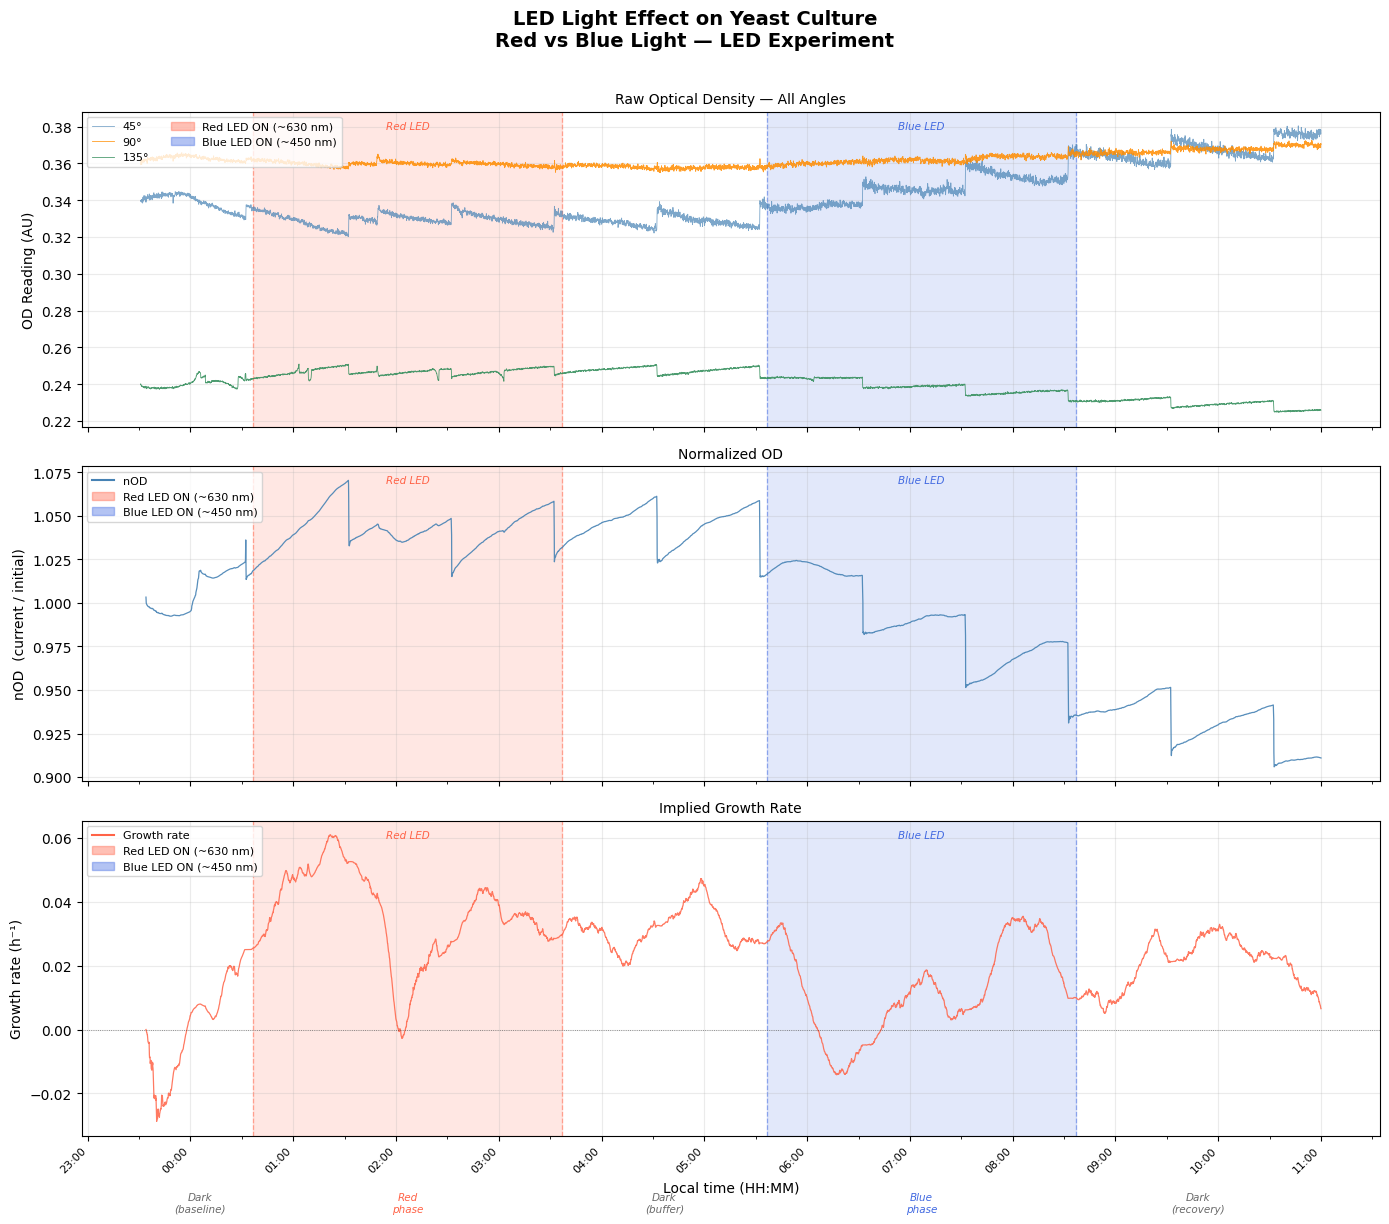

Saved: led_experiment_phases.png


In [ ]:
# 3 subplots: Raw OD | Normalized OD | Growth Rate
# Red phase (Channel C) and Blue phase (Channel D) shaded in their colours.
# X-axis: local time (HH:MM)
#

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# ── File paths ────────────────────────────────────────────────────────────────
FILE_OD   = "./data/03rd June (LED automation)/od_readings-LED_experiment-all_units-20260603115056.csv"
FILE_NOD  = "./data/03rd June (LED automation)/od_readings_filtered-LED_experiment-all_units-20260603115056.csv"
FILE_GR   = "./data/03rd June (LED automation)/growth_rates-LED_experiment-all_units-20260603115056.csv"
FILE_LED  = "./data/03rd June (LED automation)/led_change_events-LED_experiment-all_units-20260603115056.csv"

# ── Load & parse timestamps ───────────────────────────────────────────────────
od  = pd.read_csv(FILE_OD)
nod = pd.read_csv(FILE_NOD)
gr  = pd.read_csv(FILE_GR)
led = pd.read_csv(FILE_LED)

for df in [od, nod, gr, led]:
    df['t'] = pd.to_datetime(df['timestamp_localtime'])

led = led.sort_values('t')

# ── Resolve phase windows from LED events ─────────────────────────────────────
# Channel C = Red LED (~630 nm)
# Channel D = Blue LED (~450 nm)
def get_phases(led_df, channel):
    """Return list of (on_time, off_time) datetime tuples for a given channel."""
    events = led_df[led_df['channel'] == channel].sort_values('t')
    phases, on_time = [], None
    for _, row in events.iterrows():
        if row['intensity'] > 0 and on_time is None:
            on_time = row['t']
        elif row['intensity'] == 0 and on_time is not None:
            phases.append((on_time, row['t']))
            on_time = None
    return phases

red_phases  = get_phases(led, 'C')   # Channel C = Red
blue_phases = get_phases(led, 'D')   # Channel D = Blue

# ── Shading helper ────────────────────────────────────────────────────────────
def shade_phases(ax):
    for on, off in red_phases:
        ax.axvspan(on, off, color='tomato', alpha=0.15, zorder=0)
        ax.axvline(on,  color='tomato', lw=0.9, ls='--', alpha=0.5, zorder=1)
        ax.axvline(off, color='tomato', lw=0.9, ls='--', alpha=0.5, zorder=1)
        ax.text(on + (off - on) / 2, 0.97, 'Red LED',
                transform=ax.get_xaxis_transform(),
                ha='center', va='top', fontsize=7.5, color='tomato', style='italic')
    for on, off in blue_phases:
        ax.axvspan(on, off, color='royalblue', alpha=0.15, zorder=0)
        ax.axvline(on,  color='royalblue', lw=0.9, ls='--', alpha=0.5, zorder=1)
        ax.axvline(off, color='royalblue', lw=0.9, ls='--', alpha=0.5, zorder=1)
        ax.text(on + (off - on) / 2, 0.97, 'Blue LED',
                transform=ax.get_xaxis_transform(),
                ha='center', va='top', fontsize=7.5, color='royalblue', style='italic')

# ── X-axis formatter (applied to bottom subplot only; sharex propagates) ──────
def fmt_xaxis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[30]))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

# ── Legend patches ────────────────────────────────────────────────────────────
legend_patches = [
    Patch(color='tomato',    alpha=0.4, label='Red LED ON (~630 nm)'),
    Patch(color='royalblue', alpha=0.4, label='Blue LED ON (~450 nm)'),
]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('LED Light Effect on Yeast Culture\nRed vs Blue Light — LED Experiment',
             fontsize=14, fontweight='bold', y=1.01)

# ── Subplot 1: Raw OD (all angles) ────────────────────────────────────────────
ax1 = axes[0]
angle_cfg = {45: ('steelblue', 0.7), 90: ('darkorange', 0.85), 135: ('seagreen', 0.85)}
for angle, (color, alpha) in angle_cfg.items():
    sub = od[od['angle'] == angle].sort_values('t')
    ax1.plot(sub['t'], sub['od_reading'],
             color=color, lw=0.6, alpha=alpha, label=f'{angle}°')
shade_phases(ax1)
ax1.set_ylabel('OD Reading (AU)', fontsize=10)
ax1.set_title('Raw Optical Density — All Angles', fontsize=10)
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles=handles + legend_patches,
           labels=labels + [p.get_label() for p in legend_patches],
           loc='upper left', fontsize=8, ncol=2)
ax1.grid(True, alpha=0.25)

# ── Subplot 2: Normalized OD ──────────────────────────────────────────────────
ax2 = axes[1]
nod_s = nod.sort_values('t')
ax2.plot(nod_s['t'], nod_s['normalized_od_reading'],
         color='steelblue', lw=0.9, alpha=0.9)
shade_phases(ax2)
ax2.set_ylabel('nOD  (current / initial)', fontsize=10)
ax2.set_title('Normalized OD', fontsize=10)
ax2.legend(handles=[plt.Line2D([0],[0], color='steelblue', lw=1.5, label='nOD')] + legend_patches,
           loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.25)

# ── Subplot 3: Implied growth rate ────────────────────────────────────────────
ax3 = axes[2]
gr_s = gr.sort_values('t')
ax3.plot(gr_s['t'], gr_s['rate'],
         color='tomato', lw=0.9, alpha=0.85)
ax3.axhline(0, color='black', lw=0.6, ls=':', alpha=0.5)
shade_phases(ax3)
ax3.set_ylabel('Growth rate (h⁻¹)', fontsize=10)
ax3.set_title('Implied Growth Rate', fontsize=10)
ax3.set_xlabel('Local time (HH:MM)', fontsize=10)
ax3.legend(handles=[plt.Line2D([0],[0], color='tomato', lw=1.5, label='Growth rate')] + legend_patches,
           loc='upper left', fontsize=8)
ax3.grid(True, alpha=0.25)

# ── Phase labels below x-axis ─────────────────────────────────────────────────
t_min = gr_s['t'].min()
t_max = gr_s['t'].max()
phase_labels = [
    (t_min,             red_phases[0][0],  'Dark\n(baseline)', 'dimgrey'),
    (red_phases[0][0],  red_phases[0][1],  'Red\nphase',       'tomato'),
    (red_phases[0][1],  blue_phases[0][0], 'Dark\n(buffer)',   'dimgrey'),
    (blue_phases[0][0], blue_phases[0][1], 'Blue\nphase',      'royalblue'),
    (blue_phases[0][1], t_max,             'Dark\n(recovery)', 'dimgrey'),
]
for x0, x1, label, color in phase_labels:
    mid = x0 + (x1 - x0) / 2
    ax3.text(mid, -0.18, label,
             transform=ax3.get_xaxis_transform(),
             ha='center', va='top', fontsize=7.5, color=color, style='italic')

# ── Format x-axis (bottom subplot only; sharex propagates ticks up) ───────────
fmt_xaxis(ax3)

plt.tight_layout()
plt.show()


### LED Experiment 01

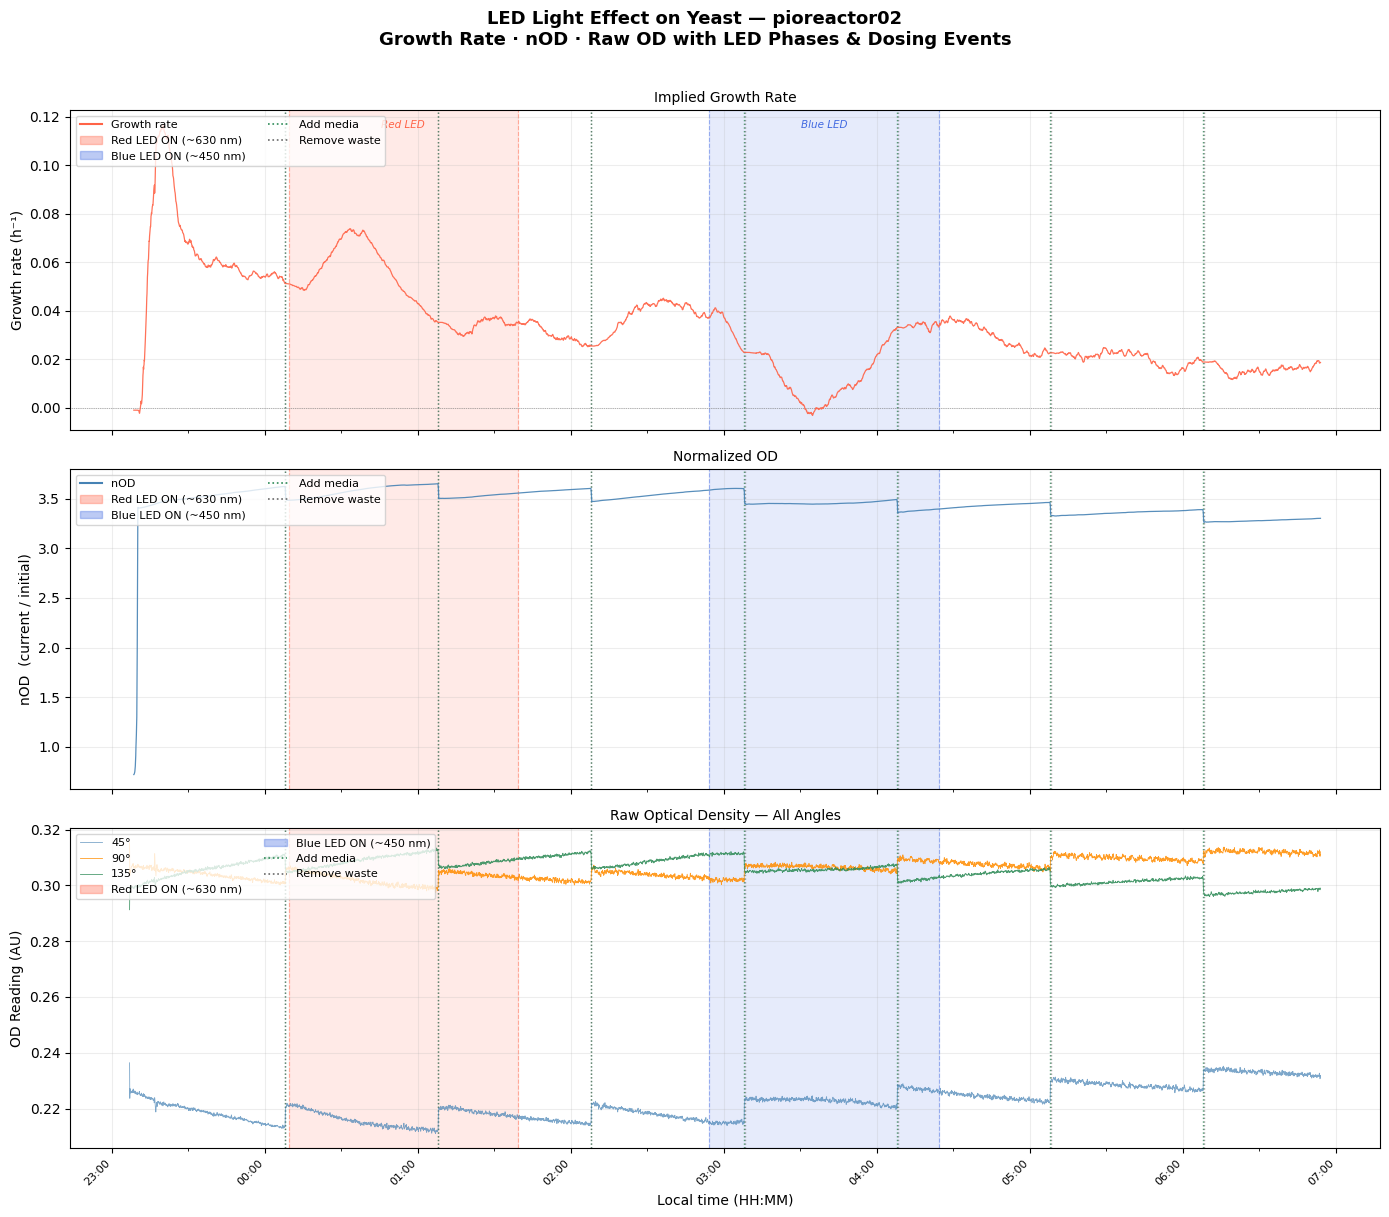

In [2]:
# 3 subplots: Growth Rate | nOD | Raw OD
# Each subplot has:
#   - Red/Blue LED phases shaded
#   - Dosing events marked as vertical lines (add_media=green, remove_waste=grey)
#

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ── File paths ────────────────────────────────────────────────────────────────
FILE_OD     = "./data/LED run 01/od_readings-LED_experiment-pioreactor02-20260606143542.csv"
FILE_NOD    = "./data/LED run 01/od_readings_filtered-LED_experiment-pioreactor02-20260606143542.csv"
FILE_GR     = "./data/LED run 01/growth_rates-LED_experiment-pioreactor02-20260606143542.csv"
FILE_LED    = "./data/LED run 01/led_change_events-LED_experiment-pioreactor02-20260606143542.csv"
FILE_DOSING = "./data/LED run 01/dosing_events-LED_experiment-pioreactor02-20260606143542.csv"

# ── Load & parse timestamps ───────────────────────────────────────────────────
od     = pd.read_csv(FILE_OD)
nod    = pd.read_csv(FILE_NOD)
gr     = pd.read_csv(FILE_GR)
led    = pd.read_csv(FILE_LED)
dosing = pd.read_csv(FILE_DOSING)

for df in [od, nod, gr, led, dosing]:
    df['t'] = pd.to_datetime(df['timestamp_localtime'])

# ── LED phases ────────────────────────────────────────────────────────────────
def get_phases(led_df, channel):
    events = led_df[led_df['channel'] == channel].sort_values('t')
    phases, on_time = [], None
    for _, row in events.iterrows():
        if row['intensity'] > 0 and on_time is None:
            on_time = row['t']
        elif row['intensity'] == 0 and on_time is not None:
            phases.append((on_time, row['t']))
            on_time = None
    return phases

red_phases  = get_phases(led, 'C')
blue_phases = get_phases(led, 'D')

# ── Dosing bursts (gap > 5 s = new burst) ────────────────────────────────────
dosing = dosing.sort_values('t')
dosing['gap'] = dosing['t'].diff().dt.total_seconds().fillna(999)
burst_starts = dosing[dosing['gap'] > 5].copy()
add_media_t    = burst_starts[burst_starts['event'] == 'add_media']['t']
remove_waste_t = burst_starts[burst_starts['event'] == 'remove_waste']['t']

# ── Shared shade + dosing helper ──────────────────────────────────────────────
def annotate_ax(ax, show_labels=False):
    # LED phase shading
    for on, off in red_phases:
        ax.axvspan(on, off, color='tomato', alpha=0.13, zorder=0)
        ax.axvline(on,  color='tomato', lw=0.8, ls='--', alpha=0.45, zorder=1)
        ax.axvline(off, color='tomato', lw=0.8, ls='--', alpha=0.45, zorder=1)
        if show_labels:
            ax.text(on + (off - on) / 2, 0.97, 'Red LED',
                    transform=ax.get_xaxis_transform(),
                    ha='center', va='top', fontsize=7.5,
                    color='tomato', style='italic')
    for on, off in blue_phases:
        ax.axvspan(on, off, color='royalblue', alpha=0.13, zorder=0)
        ax.axvline(on,  color='royalblue', lw=0.8, ls='--', alpha=0.45, zorder=1)
        ax.axvline(off, color='royalblue', lw=0.8, ls='--', alpha=0.45, zorder=1)
        if show_labels:
            ax.text(on + (off - on) / 2, 0.97, 'Blue LED',
                    transform=ax.get_xaxis_transform(),
                    ha='center', va='top', fontsize=7.5,
                    color='royalblue', style='italic')
    # Dosing events
    for t in add_media_t:
        ax.axvline(t, color='seagreen', lw=1.0, ls=':', alpha=0.8, zorder=2)
    for t in remove_waste_t:
        ax.axvline(t, color='dimgrey', lw=1.0, ls=':', alpha=0.6, zorder=2)

# ── Legend handles ────────────────────────────────────────────────────────────
legend_elements = [
    Patch(color='tomato',    alpha=0.35, label='Red LED ON (~630 nm)'),
    Patch(color='royalblue', alpha=0.35, label='Blue LED ON (~450 nm)'),
    Line2D([0],[0], color='seagreen', lw=1.2, ls=':', label='Add media'),
    Line2D([0],[0], color='dimgrey',  lw=1.2, ls=':', label='Remove waste'),
]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('LED Light Effect on Yeast — pioreactor02\nGrowth Rate · nOD · Raw OD with LED Phases & Dosing Events',
             fontsize=13, fontweight='bold', y=1.01)

# ── Subplot 1: Growth rate ────────────────────────────────────────────────────
ax1 = axes[0]
gr_s = gr.sort_values('t')
ax1.plot(gr_s['t'], gr_s['rate'], color='tomato', lw=0.9, alpha=0.9, zorder=3)
ax1.axhline(0, color='black', lw=0.5, ls=':', alpha=0.5)
annotate_ax(ax1, show_labels=True)
ax1.set_ylabel('Growth rate (h⁻¹)', fontsize=10)
ax1.set_title('Implied Growth Rate', fontsize=10)
ax1.legend(handles=[Line2D([0],[0], color='tomato', lw=1.5, label='Growth rate')] + legend_elements,
           loc='upper left', fontsize=8, ncol=2)
ax1.grid(True, alpha=0.22)

# ── Subplot 2: Normalized OD ──────────────────────────────────────────────────
ax2 = axes[1]
nod_s = nod.sort_values('t')
ax2.plot(nod_s['t'], nod_s['normalized_od_reading'], color='steelblue', lw=0.9, alpha=0.9, zorder=3)
annotate_ax(ax2)
ax2.set_ylabel('nOD  (current / initial)', fontsize=10)
ax2.set_title('Normalized OD', fontsize=10)
ax2.legend(handles=[Line2D([0],[0], color='steelblue', lw=1.5, label='nOD')] + legend_elements,
           loc='upper left', fontsize=8, ncol=2)
ax2.grid(True, alpha=0.22)

# ── Subplot 3: Raw OD (all angles) ────────────────────────────────────────────
ax3 = axes[2]
angle_cfg = {45: ('steelblue', 0.70), 90: ('darkorange', 0.85), 135: ('seagreen', 0.85)}
for angle, (color, alpha) in angle_cfg.items():
    sub = od[od['angle'] == angle].sort_values('t')
    ax3.plot(sub['t'], sub['od_reading'], color=color, lw=0.6, alpha=alpha,
             label=f'{angle}°', zorder=3)
annotate_ax(ax3)
ax3.set_ylabel('OD Reading (AU)', fontsize=10)
ax3.set_title('Raw Optical Density — All Angles', fontsize=10)
ax3.set_xlabel('Local time (HH:MM)', fontsize=10)
od_handles, od_labels = ax3.get_legend_handles_labels()
ax3.legend(handles=od_handles + legend_elements,
           labels=od_labels + [e.get_label() for e in legend_elements],
           loc='upper left', fontsize=8, ncol=2)
ax3.grid(True, alpha=0.22)

# ── X-axis formatting (bottom only; sharex propagates) ───────────────────────
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax3.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax3.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[30]))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()


### LED Experiment 02

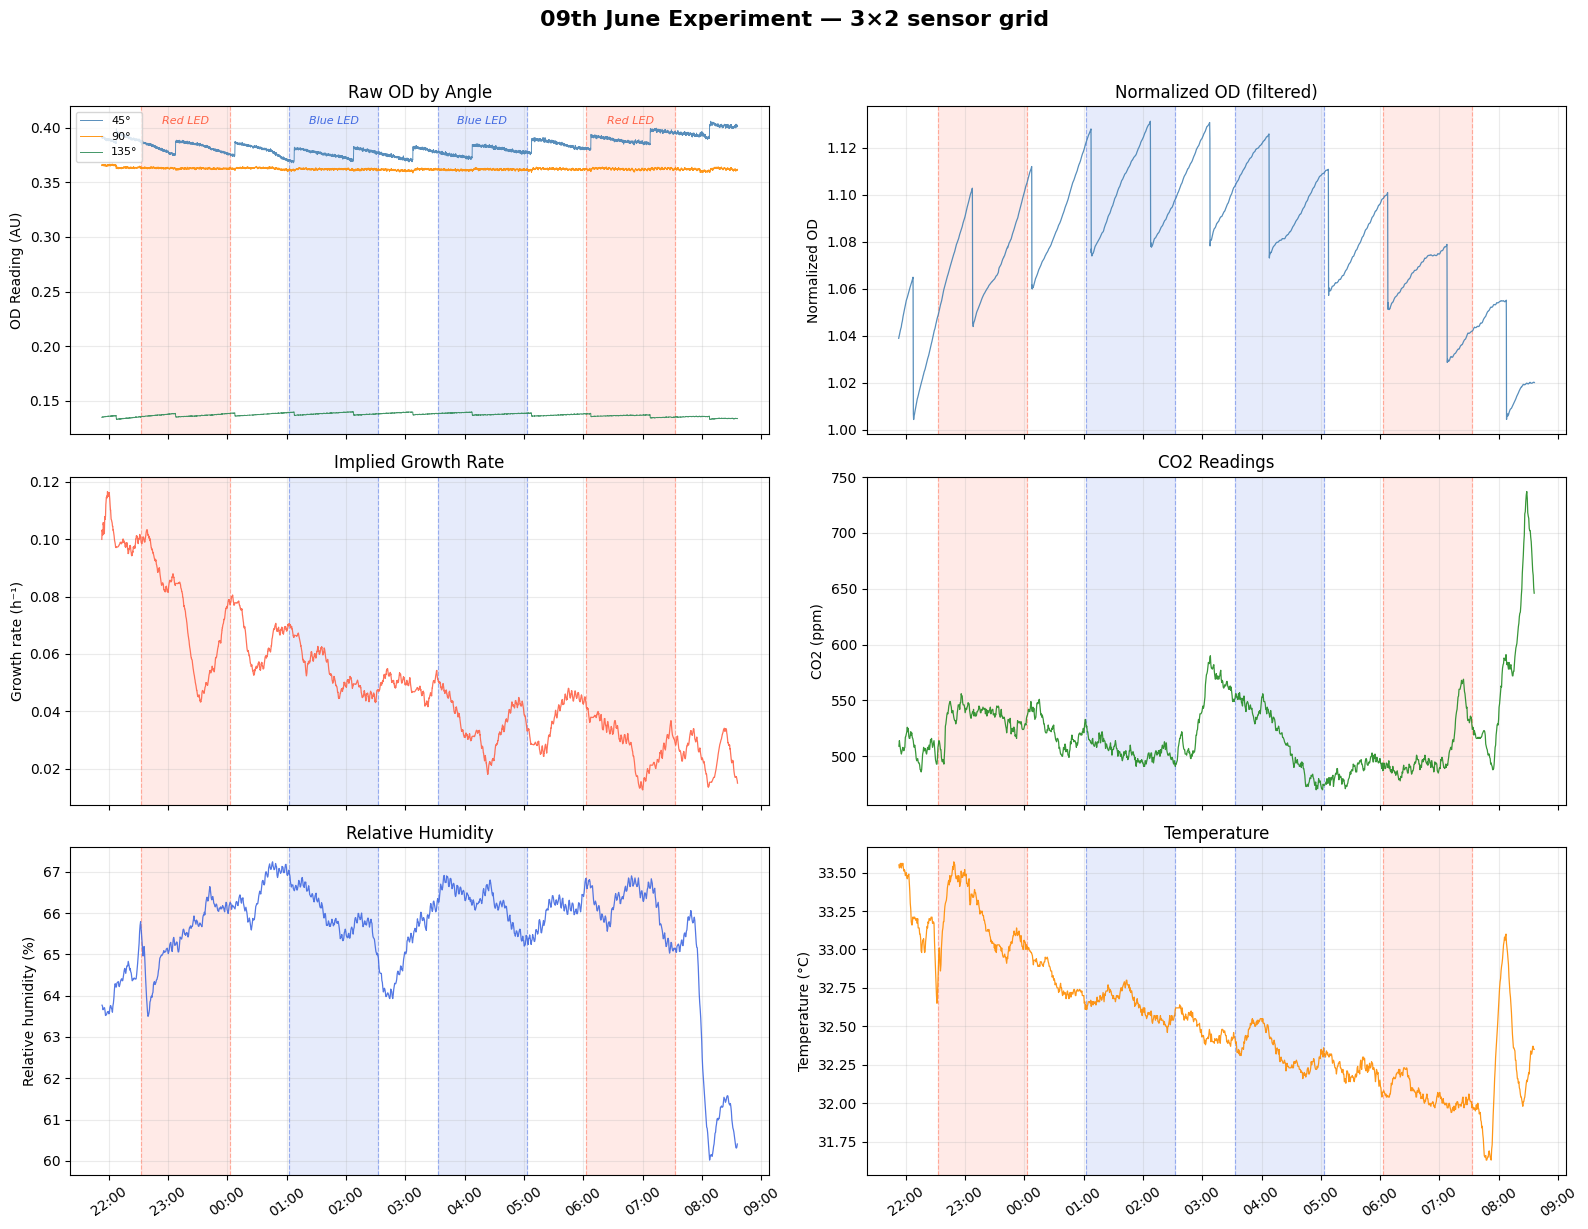

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

BASE = "./data/09th June/"
FILE_OD    = BASE + "od_readings-all_experiments-pioreactor01-20260609144657.csv"
FILE_NOD   = BASE + "od_readings_filtered-all_experiments-pioreactor01-20260609144657.csv"
FILE_GR    = BASE + "growth_rates-all_experiments-pioreactor01-20260609144657.csv"
FILE_LED   = BASE + "led_change_events-all_experiments-pioreactor01-20260609144657.csv"
FILE_CO2   = BASE + "co2_readings-experiment_June-all_units-20260609162412.csv"

od   = pd.read_csv(FILE_OD)
nod  = pd.read_csv(FILE_NOD)
gr   = pd.read_csv(FILE_GR)
led  = pd.read_csv(FILE_LED)
co2  = pd.read_csv(FILE_CO2)

for df in [od, nod, gr, led, co2]:
    df['t'] = pd.to_datetime(df['timestamp_localtime'])


def get_phases(led_df, channel):
    events = led_df[led_df['channel'] == channel].sort_values('t')
    phases, on_time = [], None
    for _, row in events.iterrows():
        if row['intensity'] > 0 and on_time is None:
            on_time = row['t']
        elif row['intensity'] == 0 and on_time is not None:
            phases.append((on_time, row['t']))
            on_time = None
    return phases

red_phases  = get_phases(led, 'C')
blue_phases = get_phases(led, 'D')


def annotate_ax(ax, show_labels=False):
    for on, off in red_phases:
        ax.axvspan(on, off, color='tomato', alpha=0.13, zorder=0)
        ax.axvline(on,  color='tomato', lw=0.8, ls='--', alpha=0.45, zorder=1)
        ax.axvline(off, color='tomato', lw=0.8, ls='--', alpha=0.45, zorder=1)
        if show_labels:
            ax.text(on + (off - on) / 2, 0.97, 'Red LED',
                    transform=ax.get_xaxis_transform(), ha='center', va='top',
                    fontsize=8, color='tomato', style='italic')
    for on, off in blue_phases:
        ax.axvspan(on, off, color='royalblue', alpha=0.13, zorder=0)
        ax.axvline(on,  color='royalblue', lw=0.8, ls='--', alpha=0.45, zorder=1)
        ax.axvline(off, color='royalblue', lw=0.8, ls='--', alpha=0.45, zorder=1)
        if show_labels:
            ax.text(on + (off - on) / 2, 0.97, 'Blue LED',
                    transform=ax.get_xaxis_transform(), ha='center', va='top',
                    fontsize=8, color='royalblue', style='italic')


fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()
fig.suptitle('09th June Experiment — 3×2 sensor grid', fontsize=16, fontweight='bold', y=1.02)

# Raw OD
ax = axes[0]
for angle, color in [(45, 'steelblue'), (90, 'darkorange'), (135, 'seagreen')]:
    subset = od[od['angle'] == angle].sort_values('t')
    ax.plot(subset['t'], subset['od_reading'], color=color, lw=0.7, alpha=0.9, label=f'{angle}°')
annotate_ax(ax, show_labels=True)
ax.set_ylabel('OD Reading (AU)')
ax.set_title('Raw OD by Angle')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.25)

# Normalized OD
ax = axes[1]
nod_s = nod.sort_values('t')
ax.plot(nod_s['t'], nod_s['normalized_od_reading'], color='steelblue', lw=0.9, alpha=0.9)
annotate_ax(ax)
ax.set_ylabel('Normalized OD')
ax.set_title('Normalized OD (filtered)')
ax.grid(True, alpha=0.25)

# Growth rate
ax = axes[2]
gr_s = gr.sort_values('t')
ax.plot(gr_s['t'], gr_s['rate'], color='tomato', lw=0.9, alpha=0.9)
annotate_ax(ax)
ax.set_ylabel('Growth rate (h⁻¹)')
ax.set_title('Implied Growth Rate')
ax.grid(True, alpha=0.25)

# CO2 readings
ax = axes[3]
co2_s = co2.sort_values('t')
ax.plot(co2_s['t'], co2_s['co2_reading_ppm'], color='forestgreen', lw=0.9, alpha=0.9)
annotate_ax(ax)
ax.set_ylabel('CO2 (ppm)')
ax.set_title('CO2 Readings')
ax.grid(True, alpha=0.25)

# Relative humidity
ax = axes[4]
ax.plot(co2_s['t'], co2_s['relative_humidity'], color='royalblue', lw=0.9, alpha=0.9)
annotate_ax(ax)
ax.set_ylabel('Relative humidity (%)')
ax.set_title('Relative Humidity')
ax.grid(True, alpha=0.25)

# Temperature
ax = axes[5]
ax.plot(co2_s['t'], co2_s['temperature_c'], color='darkorange', lw=0.9, alpha=0.9)
annotate_ax(ax)
ax.set_ylabel('Temperature (°C)')
ax.set_title('Temperature')
ax.grid(True, alpha=0.25)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()


### LED Experiment 03

Red phases: 4  |  Blue phases: 4


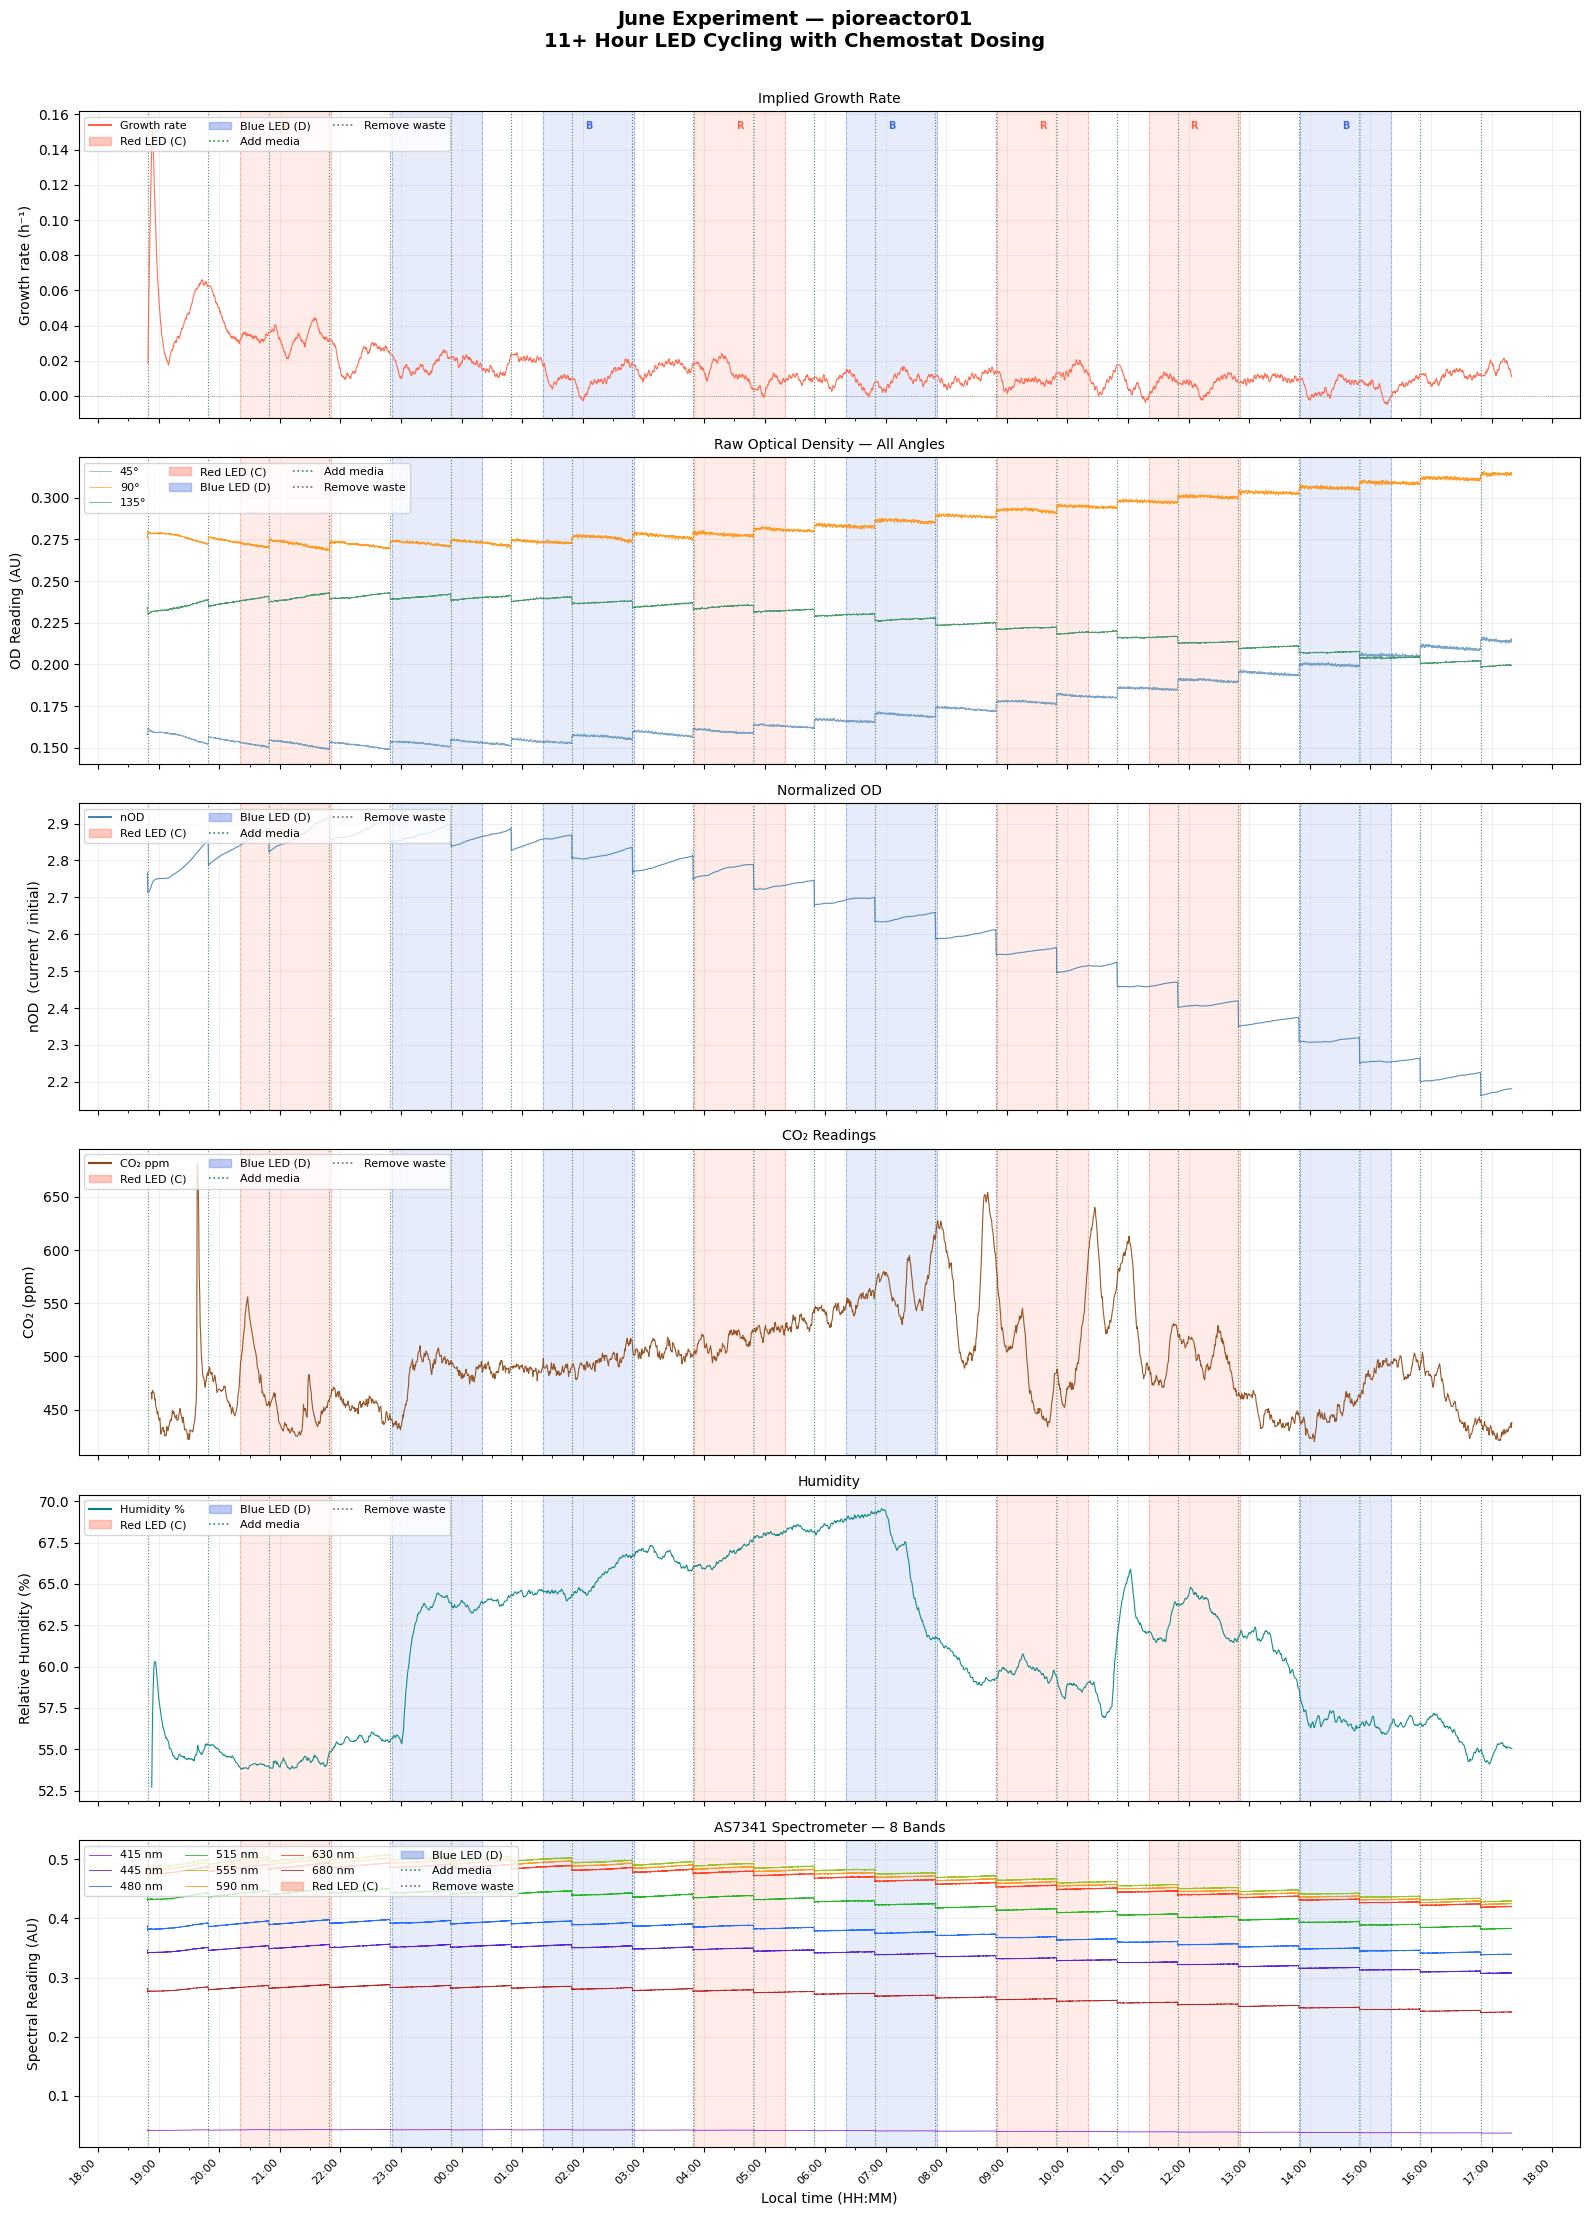

In [ ]:
# 6 subplots:
#   1. Growth Rate
#   2. Raw OD (all angles)
#   3. Normalized OD
#   4. CO2 (ppm)
#   5. Relative Humidity (%)
#   6. AS7341 Spectrometer (all 8 bands)
#
#   - Red LED phases (channel C) shaded red
#   - Blue LED phases (channel D) shaded blue
#   - Dosing events: add_media (green dotted) | remove_waste (grey dotted)
#

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ── File paths ────────────────────────────────────────────────────────────────
BASE = "./data/10th June/"
FILE_GROWTH = BASE + "growth_rates-experiment_June-all_units-20260610173842.csv"
FILE_OD = BASE + "od_readings-experiment_June-all_units-20260610173842.csv"
FILE_NOD = BASE + "od_readings_filtered-experiment_June-all_units-20260610173842.csv"
FILE_CO2 = BASE + "co2_readings-experiment_June-all_units-20260610173842.csv"
FILE_SPEC = BASE + "as7341_spectrum_readings-experiment_June-all_units-20260610173842.csv"
FILE_LED = BASE + "led_change_events-experiment_June-all_units-20260610173842.csv"
FILE_DOSING = BASE + "dosing_events-experiment_June-all_units-20260610173842.csv"

# ── Load ──────────────────────────────────────────────────────────────────────
def load(path):
    with open(path, 'rb') as f:
        df = pd.read_csv(f)
    df['t'] = pd.to_datetime(df['timestamp_localtime'])
    return df

od     = load(FILE_OD)
nod    = load(FILE_NOD)
gr     = load(FILE_GROWTH)
led    = load(FILE_LED)
dosing = load(FILE_DOSING)
co2    = load(FILE_CO2)
spec   = load(FILE_SPEC)

# ── LED phases ────────────────────────────────────────────────────────────────
def get_phases(led_df, channel):
    events = led_df[led_df['channel'] == channel].sort_values('t')
    phases, on_time = [], None
    for _, row in events.iterrows():
        if row['intensity'] > 0 and on_time is None:
            on_time = row['t']
        elif row['intensity'] == 0 and on_time is not None:
            phases.append((on_time, row['t']))
            on_time = None
    return phases

red_phases  = get_phases(led, 'C')
blue_phases = get_phases(led, 'D')
print(f"Red phases: {len(red_phases)}  |  Blue phases: {len(blue_phases)}")

# ── Dosing bursts (gap > 5 s = new burst) ────────────────────────────────────
dosing = dosing.sort_values('t')
dosing['gap'] = dosing['t'].diff().dt.total_seconds().fillna(999)
bursts         = dosing[dosing['gap'] > 5]
add_media_t    = bursts[bursts['event'] == 'add_media']['t']
remove_waste_t = bursts[bursts['event'] == 'remove_waste']['t']

# ── Spectrometer pivot ────────────────────────────────────────────────────────
# Floor to second so all 8 bands per measurement share the same timestamp key
spec['t_sec'] = spec['t'].dt.floor('s')
spec_pivot = (spec.pivot_table(index='t_sec', columns='band',
                               values='reading', aggfunc='mean')
                  .reset_index()
                  .rename(columns={'t_sec': 't'}))

BAND_COLORS = {
    415: '#7B00D4', 445: '#3D00CC', 480: '#0055FF',
    515: '#00AA00', 555: '#88BB00', 590: '#FF8800',
    630: '#FF2200', 680: '#AA0000',
}

# ── Annotation helper ─────────────────────────────────────────────────────────
def annotate_ax(ax, show_labels=False):
    for on, off in red_phases:
        ax.axvspan(on, off, color='tomato', alpha=0.12, zorder=0)
        ax.axvline(on,  color='tomato', lw=0.7, ls='--', alpha=0.4, zorder=1)
        ax.axvline(off, color='tomato', lw=0.7, ls='--', alpha=0.4, zorder=1)
        if show_labels:
            ax.text(on + (off - on) / 2, 0.97, 'R',
                    transform=ax.get_xaxis_transform(),
                    ha='center', va='top', fontsize=7, color='tomato', fontweight='bold')
    for on, off in blue_phases:
        ax.axvspan(on, off, color='royalblue', alpha=0.12, zorder=0)
        ax.axvline(on,  color='royalblue', lw=0.7, ls='--', alpha=0.4, zorder=1)
        ax.axvline(off, color='royalblue', lw=0.7, ls='--', alpha=0.4, zorder=1)
        if show_labels:
            ax.text(on + (off - on) / 2, 0.97, 'B',
                    transform=ax.get_xaxis_transform(),
                    ha='center', va='top', fontsize=7, color='royalblue', fontweight='bold')
    for t in add_media_t:
        ax.axvline(t, color='seagreen', lw=0.8, ls=':', alpha=0.7, zorder=2)
    for t in remove_waste_t:
        ax.axvline(t, color='dimgrey',  lw=0.8, ls=':', alpha=0.5, zorder=2)

def fmt_xaxis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[30]))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

# ── Legend handles ────────────────────────────────────────────────────────────
shared_legend = [
    Patch(color='tomato',    alpha=0.35, label='Red LED (C)'),
    Patch(color='royalblue', alpha=0.35, label='Blue LED (D)'),
    Line2D([0],[0], color='seagreen', lw=1.2, ls=':', label='Add media'),
    Line2D([0],[0], color='dimgrey',  lw=1.2, ls=':', label='Remove waste'),
]

# ── Figure: 6 rows × 1 col ────────────────────────────────────────────────────
fig, axes = plt.subplots(6, 1, figsize=(16, 22), sharex=True)
fig.suptitle('June Experiment — pioreactor01\n11+ Hour LED Cycling with Chemostat Dosing',
             fontsize=14, fontweight='bold', y=1.005)

# ── 1. Growth rate ────────────────────────────────────────────────────────────
ax = axes[0]
gr_s = gr.sort_values('t')
ax.plot(gr_s['t'], gr_s['rate'], color='tomato', lw=0.8, alpha=0.9, zorder=3)
ax.axhline(0, color='black', lw=0.5, ls=':', alpha=0.5)
annotate_ax(ax, show_labels=True)
ax.set_ylabel('Growth rate (h⁻¹)', fontsize=10)
ax.set_title('Implied Growth Rate', fontsize=10)
ax.legend(handles=[Line2D([0],[0], color='tomato', lw=1.5, label='Growth rate')] + shared_legend,
          fontsize=8, loc='upper left', ncol=3)
ax.grid(True, alpha=0.2)

# ── 2. Raw OD ─────────────────────────────────────────────────────────────────
ax = axes[1]
for angle, (color, alpha) in {45:('steelblue',0.70), 90:('darkorange',0.85), 135:('seagreen',0.85)}.items():
    sub = od[od['angle'] == angle].sort_values('t')
    ax.plot(sub['t'], sub['od_reading'], color=color, lw=0.5, alpha=alpha, label=f'{angle}°', zorder=3)
annotate_ax(ax)
ax.set_ylabel('OD Reading (AU)', fontsize=10)
ax.set_title('Raw Optical Density — All Angles', fontsize=10)
od_h, od_l = ax.get_legend_handles_labels()
ax.legend(handles=od_h + shared_legend, labels=od_l + [e.get_label() for e in shared_legend],
          fontsize=8, loc='upper left', ncol=3)
ax.grid(True, alpha=0.2)

# ── 3. Normalized OD ──────────────────────────────────────────────────────────
ax = axes[2]
nod_s = nod.sort_values('t')
ax.plot(nod_s['t'], nod_s['normalized_od_reading'], color='steelblue', lw=0.8, alpha=0.9, zorder=3)
annotate_ax(ax)
ax.set_ylabel('nOD  (current / initial)', fontsize=10)
ax.set_title('Normalized OD', fontsize=10)
ax.legend(handles=[Line2D([0],[0], color='steelblue', lw=1.5, label='nOD')] + shared_legend,
          fontsize=8, loc='upper left', ncol=3)
ax.grid(True, alpha=0.2)

# ── 4. CO2 ────────────────────────────────────────────────────────────────────
ax = axes[3]
co2_s = co2.sort_values('t')
ax.plot(co2_s['t'], co2_s['co2_reading_ppm'], color='saddlebrown', lw=0.8, alpha=0.9, zorder=3)
annotate_ax(ax)
ax.set_ylabel('CO₂ (ppm)', fontsize=10)
ax.set_title('CO₂ Readings', fontsize=10)
ax.legend(handles=[Line2D([0],[0], color='saddlebrown', lw=1.5, label='CO₂ ppm')] + shared_legend,
          fontsize=8, loc='upper left', ncol=3)
ax.grid(True, alpha=0.2)

# ── 5. Humidity ───────────────────────────────────────────────────────────────
ax = axes[4]
ax.plot(co2_s['t'], co2_s['relative_humidity'], color='teal', lw=0.8, alpha=0.9, zorder=3)
annotate_ax(ax)
ax.set_ylabel('Relative Humidity (%)', fontsize=10)
ax.set_title('Humidity', fontsize=10)
ax.legend(handles=[Line2D([0],[0], color='teal', lw=1.5, label='Humidity %')] + shared_legend,
          fontsize=8, loc='upper left', ncol=3)
ax.grid(True, alpha=0.2)

# ── 6. AS7341 spectrometer ────────────────────────────────────────────────────
ax = axes[5]
band_cols = [c for c in spec_pivot.columns if c != 't']
for band in sorted(band_cols):
    ax.plot(spec_pivot['t'], spec_pivot[band],
            color=BAND_COLORS.get(band, 'grey'),
            lw=0.6, alpha=0.85, label=f'{band} nm', zorder=3)
annotate_ax(ax)
ax.set_ylabel('Spectral Reading (AU)', fontsize=10)
ax.set_title('AS7341 Spectrometer — 8 Bands', fontsize=10)
ax.set_xlabel('Local time (HH:MM)', fontsize=10)
spec_h, spec_l = ax.get_legend_handles_labels()
ax.legend(handles=spec_h + shared_legend,
          labels=spec_l + [e.get_label() for e in shared_legend],
          fontsize=8, loc='upper left', ncol=4)
ax.grid(True, alpha=0.2)

# ── X-axis: only bottom subplot needs labels (sharex propagates ticks) ────────
fmt_xaxis(axes[5])

plt.tight_layout()
plt.show()

### Analysis

In [17]:
import numpy as np
import pandas as pd
from scipy.stats import linregress, ttest_ind
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [18]:
def load(path):
    with open(path, 'rb') as f:
        df = pd.read_csv(f)
    df['t'] = pd.to_datetime(df['timestamp_localtime'])
    return df
 
growth = load("./data/10th June/growth_rates-experiment_June-all_units-20260610173842.csv")
od     = load("./data/10th June/od_readings_filtered-experiment_June-all_units-20260610173842.csv")
co2    = load("./data/10th June/co2_readings-experiment_June-all_units-20260610173842.csv")
led    = load("./data/10th June/led_change_events-experiment_June-all_units-20260610173842.csv")
spec   = load("./data/10th June/as7341_spectrum_readings-experiment_June-all_units-20260610173842.csv")

In [19]:
led_ev = led.sort_values('t').reset_index(drop=True)
 
phases = []
current = 'dark'
t_start = growth['t'].min()          # experiment start
 
for _, row in led_ev.iterrows():
    t_end = row['t']
    if t_end > t_start:
        phases.append({'start': t_start, 'end': t_end, 'phase': current})
    # update current phase based on this event
    if row['channel'] == 'C' and row['intensity'] > 0:
        current = 'red'
    elif row['channel'] == 'D' and row['intensity'] > 0:
        current = 'blue'
    else:
        pass
    t_start = t_end
 
# final segment after last event
phases.append({'start': t_start, 'end': growth['t'].max(), 'phase': current})
phases_df = pd.DataFrame(phases)
 
ch_state = {'C': 0.0, 'D': 0.0}
phases2 = []
current_phase = 'dark'
t_start = growth['t'].min()
 
for _, row in led_ev.iterrows():
    t_end = row['t']
    if t_end > t_start:
        phases2.append({'start': t_start, 'end': t_end, 'phase': current_phase})
    ch_state[row['channel']] = row['intensity']
    if ch_state['C'] > 0:
        current_phase = 'red'
    elif ch_state['D'] > 0:
        current_phase = 'blue'
    else:
        current_phase = 'dark'
    t_start = t_end
 
phases2.append({'start': t_start, 'end': growth['t'].max(), 'phase': current_phase})
phases_df = pd.DataFrame(phases2)
 
print("Phase schedule:")
for _, p in phases_df.iterrows():
    dur = (p['end'] - p['start']).total_seconds() / 60
    print(f"  {p['phase']:5s}  {p['start'].strftime('%H:%M')} → {p['end'].strftime('%H:%M')}  ({dur:.0f} min)")

Phase schedule:
  dark   18:49 → 18:50  (2 min)
  dark   18:50 → 20:20  (90 min)
  red    20:20 → 21:50  (90 min)
  dark   21:50 → 22:50  (60 min)
  blue   22:50 → 00:20  (90 min)
  dark   00:20 → 01:20  (60 min)
  blue   01:20 → 02:50  (90 min)
  dark   02:50 → 03:50  (60 min)
  red    03:50 → 05:20  (90 min)
  dark   05:20 → 06:20  (60 min)
  blue   06:20 → 07:50  (90 min)
  dark   07:50 → 08:50  (60 min)
  red    08:50 → 10:20  (90 min)
  dark   10:20 → 11:20  (60 min)
  red    11:20 → 12:50  (90 min)
  dark   12:50 → 13:50  (60 min)
  blue   13:50 → 15:20  (90 min)
  dark   15:20 → 15:24  (4 min)
  dark   15:24 → 17:19  (115 min)


In [21]:
def assign_phase(df, phases_df):
    df = df.copy()
    df['phase'] = 'unknown'
    for _, p in phases_df.iterrows():
        mask = (df['t'] >= p['start']) & (df['t'] < p['end'])
        df.loc[mask, 'phase'] = p['phase']
    return df
 
growth = assign_phase(growth, phases_df)
od     = assign_phase(od,     phases_df)
co2    = assign_phase(co2,    phases_df)
spec   = assign_phase(spec,   phases_df)

# strip startup (90 mins dark baseline)
t0 = growth['t'].min()
cutoff = t0 + pd.Timedelta(minutes=90)
growth = growth[growth['t'] > cutoff].copy()
od     = od[od['t']     > cutoff].copy()
co2    = co2[co2['t']   > cutoff].copy()
spec   = spec[spec['t'] > cutoff].copy()
 

In [22]:
# Mean Growth rate per phase 

def bootstrap_ci(data, n=5000, ci=95):
    means = [np.mean(np.random.choice(data, len(data), replace=True)) for _ in range(n)]
    lo, hi = np.percentile(means, [(100-ci)/2, 100-(100-ci)/2])
    return lo, hi
 
print("\n─── Mean growth rate per phase (h⁻¹) ───")
growth_summary = {}
for phase, grp in growth.groupby('phase'):
    vals = grp['rate'].dropna().values
    lo, hi = bootstrap_ci(vals)
    growth_summary[phase] = {'mean': np.mean(vals), 'std': np.std(vals),
                              'ci_lo': lo, 'ci_hi': hi, 'n': len(vals)}
    print(f"  {phase:6s}  mean={np.mean(vals):.4f}  std={np.std(vals):.4f}  "
          f"95%CI=[{lo:.4f}, {hi:.4f}]  n={len(vals)}")
 
# t-tests vs dark
dark_vals = growth[growth['phase']=='dark']['rate'].dropna().values
for phase in ['red','blue']:
    if phase in growth['phase'].values:
        phase_vals = growth[growth['phase']==phase]['rate'].dropna().values
        t, p = ttest_ind(dark_vals, phase_vals)
        print(f"  t-test dark vs {phase}: t={t:.3f}, p={p:.4f}  "
              f"{'*significant*' if p < 0.05 else 'not significant'}")


─── Mean growth rate per phase (h⁻¹) ───
  blue    mean=0.0104  std=0.0066  95%CI=[0.0102, 0.0106]  n=4151
  dark    mean=0.0128  std=0.0063  95%CI=[0.0127, 0.0130]  n=6190
  red     mean=0.0158  std=0.0114  95%CI=[0.0155, 0.0162]  n=4155
  unknown  mean=0.0110  std=0.0000  95%CI=[0.0110, 0.0110]  n=1
  t-test dark vs red: t=-17.096, p=0.0000  *significant*
  t-test dark vs blue: t=18.700, p=0.0000  *significant*


In [23]:
# nOD slope per phase

print("\n─── nOD slope per phase instance (h⁻¹) ───")
nod_slopes = []
for _, p in phases_df.iterrows():
    grp = od[(od['t'] >= p['start']) & (od['t'] < p['end'])].sort_values('t')
    if len(grp) < 10:
        continue
    x = (grp['t'] - grp['t'].iloc[0]).dt.total_seconds() / 3600
    y = grp['normalized_od_reading'].values
    slope, intercept, r, pval, se = linregress(x, y)
    nod_slopes.append({'phase': p['phase'],
                       'start': p['start'].strftime('%H:%M'),
                       'slope_per_h': slope, 'r2': r**2, 'p': pval,
                       'duration_min': (p['end']-p['start']).total_seconds()/60})
    print(f"  {p['phase']:5s} @{p['start'].strftime('%H:%M')}  "
          f"slope={slope:+.4f} nOD/h  r²={r**2:.3f}  p={pval:.4f}")
 
nod_slopes_df = pd.DataFrame(nod_slopes)
print("\n  Mean slope by phase type:")
print(nod_slopes_df.groupby('phase')['slope_per_h'].mean().to_string())


─── nOD slope per phase instance (h⁻¹) ───
  dark  @18:50  slope=+0.0883 nOD/h  r²=0.958  p=0.0000
  red   @20:20  slope=+0.0358 nOD/h  r²=0.417  p=0.0000
  dark  @21:50  slope=+0.0547 nOD/h  r²=0.735  p=0.0000
  blue  @22:50  slope=-0.0021 nOD/h  r²=0.003  p=0.0632
  dark  @00:20  slope=-0.0331 nOD/h  r²=0.315  p=0.0000
  blue  @01:20  slope=-0.0333 nOD/h  r²=0.348  p=0.0000
  dark  @02:50  slope=+0.0388 nOD/h  r²=0.609  p=0.0000
  red   @03:50  slope=-0.0315 nOD/h  r²=0.301  p=0.0000
  dark  @05:20  slope=-0.0758 nOD/h  r²=0.631  p=0.0000
  blue  @06:20  slope=-0.0401 nOD/h  r²=0.426  p=0.0000
  dark  @07:50  slope=+0.0168 nOD/h  r²=0.190  p=0.0000
  red   @08:50  slope=-0.0362 nOD/h  r²=0.442  p=0.0000
  dark  @10:20  slope=-0.0850 nOD/h  r²=0.705  p=0.0000
  red   @11:20  slope=-0.0469 nOD/h  r²=0.522  p=0.0000
  dark  @12:50  slope=+0.0149 nOD/h  r²=0.159  p=0.0000
  blue  @13:50  slope=-0.0482 nOD/h  r²=0.575  p=0.0000
  dark  @15:20  slope=+0.0135 nOD/h  r²=0.670  p=0.0000
  da

Mean slope by phase type:

phase

blue   -0.030916 -> culture density declines in blue light

dark   -0.001108 

red    -0.019692 -> density decline continues but less steeply than blue

In [24]:
print("\n─── CO₂ slope per phase instance (ppm/h) ───")
co2_slopes = []
for _, p in phases_df.iterrows():
    grp = co2[(co2['t'] >= p['start']) & (co2['t'] < p['end'])].dropna(subset=['co2_reading_ppm']).sort_values('t')
    if len(grp) < 5:
        continue
    x = (grp['t'] - grp['t'].iloc[0]).dt.total_seconds() / 3600
    y = grp['co2_reading_ppm'].values
    slope, _, r, pval, _ = linregress(x, y)
    co2_slopes.append({'phase': p['phase'], 'start': p['start'].strftime('%H:%M'),
                       'slope_ppm_per_h': slope, 'r2': r**2, 'p': pval})
    print(f"  {p['phase']:5s} @{p['start'].strftime('%H:%M')}  "
          f"slope={slope:+.1f} ppm/h  r²={r**2:.3f}")
 
co2_slopes_df = pd.DataFrame(co2_slopes)
print("\n  Mean CO₂ slope by phase type:")
print(co2_slopes_df.groupby('phase')['slope_ppm_per_h'].mean().to_string())
 


─── CO₂ slope per phase instance (ppm/h) ───
  red   @20:20  slope=-41.8 ppm/h  r²=0.388
  dark  @21:50  slope=-19.7 ppm/h  r²=0.511
  blue  @22:50  slope=+24.1 ppm/h  r²=0.248
  dark  @00:20  slope=-1.8 ppm/h  r²=0.022
  blue  @01:20  slope=+14.6 ppm/h  r²=0.598
  dark  @02:50  slope=-4.0 ppm/h  r²=0.046
  red   @03:50  slope=+15.2 ppm/h  r²=0.526
  dark  @05:20  slope=+16.6 ppm/h  r²=0.409
  blue  @06:20  slope=+18.7 ppm/h  r²=0.187
  dark  @07:50  slope=+16.6 ppm/h  r²=0.008
  red   @08:50  slope=-17.8 ppm/h  r²=0.042
  dark  @10:20  slope=-93.8 ppm/h  r²=0.364
  red   @11:20  slope=-0.6 ppm/h  r²=0.000
  dark  @12:50  slope=-29.6 ppm/h  r²=0.552
  blue  @13:50  slope=+48.9 ppm/h  r²=0.903
  dark  @15:20  slope=+61.4 ppm/h  r²=0.553
  dark  @15:24  slope=-44.9 ppm/h  r²=0.860

  Mean CO₂ slope by phase type:
phase
blue    26.575705
dark   -11.017194
red    -11.256598


Mean CO₂ slope by phase type:

phase

blue    26.575705  (blue-light → reactive oxygen species → disrupted respiration → metabolic shift toward fermentation pathway)

dark   -11.017194

red    -11.256598

Transition Response (LED switch events)

- blue_on: Δ = -0.0081 h⁻¹ — growth rate drops immediately when blue turns on
- red_on: Δ = +0.0004 h⁻¹ — essentially no immediate change (effect builds slowly)

In [33]:
print("\n─── Transition response (Δ growth rate ±30 min) ───")
window = pd.Timedelta(minutes=30)
transitions = []
for _, row in led_ev.iterrows():
    t0_ev = row['t']
    before = growth[(growth['t'] >= t0_ev - window) & (growth['t'] < t0_ev)]
    after  = growth[(growth['t'] >= t0_ev)           & (growth['t'] < t0_ev + window)]
    if len(before) < 10 or len(after) < 10:
        continue
    delta = after['rate'].mean() - before['rate'].mean()
    label = ('red_on'   if row['channel']=='C' and row['intensity']>0 else
             'blue_on'  if row['channel']=='D' and row['intensity']>0 else
             f"ch{row['channel']}_off")
    transitions.append({'event': label, 'time': t0_ev.strftime('%H:%M'),
                        'mean_before': before['rate'].mean(),
                        'mean_after':  after['rate'].mean(),
                        'delta': delta})
    print(f"  {label:12s} @{t0_ev.strftime('%H:%M')}  "
          f"before={before['rate'].mean():.4f}  after={after['rate'].mean():.4f}  "
          f"Δ={delta:+.4f}")
 
trans_df = pd.DataFrame(transitions)
if not trans_df.empty:
    print("\n  Mean Δ by event type:")
    print(trans_df.groupby('event')['delta'].mean().to_string())


─── Transition response (Δ growth rate ±30 min) ───
  red_on       @20:20  before=0.0306  after=0.0337  Δ=+0.0031
  chD_off      @20:20  before=0.0306  after=0.0337  Δ=+0.0031
  chC_off      @21:50  before=0.0356  after=0.0174  Δ=-0.0181
  chD_off      @21:50  before=0.0356  after=0.0174  Δ=-0.0181
  chC_off      @22:50  before=0.0269  after=0.0156  Δ=-0.0113
  blue_on      @22:50  before=0.0269  after=0.0156  Δ=-0.0113
  chC_off      @00:20  before=0.0196  after=0.0150  Δ=-0.0047
  chD_off      @00:20  before=0.0196  after=0.0150  Δ=-0.0047
  chC_off      @01:20  before=0.0212  after=0.0098  Δ=-0.0114
  blue_on      @01:20  before=0.0212  after=0.0098  Δ=-0.0114
  chC_off      @02:50  before=0.0151  after=0.0142  Δ=-0.0009
  chD_off      @02:50  before=0.0151  after=0.0142  Δ=-0.0009
  red_on       @03:50  before=0.0175  after=0.0176  Δ=+0.0001
  chD_off      @03:50  before=0.0175  after=0.0176  Δ=+0.0001
  chD_off      @05:20  before=0.0066  after=0.0100  Δ=+0.0034
  chC_off      @0

In [34]:
print("\n─── Relative growth effect vs surrounding dark periods ───")
rel_effects = []
for i in range(1, len(phases_df)-1):
    cur  = phases_df.iloc[i]
    prev = phases_df.iloc[i-1]
    nxt  = phases_df.iloc[i+1]
    if prev['phase'] != 'dark' or nxt['phase'] != 'dark':
        continue
    cur_gr   = growth[(growth['t'] >= cur['start'])  & (growth['t'] < cur['end'])]['rate'].dropna()
    dark_bef = growth[(growth['t'] >= prev['start']) & (growth['t'] < prev['end'])]['rate'].dropna()
    dark_aft = growth[(growth['t'] >= nxt['start'])  & (growth['t'] < nxt['end'])]['rate'].dropna()
    if len(cur_gr)<5 or len(dark_bef)<5 or len(dark_aft)<5:
        continue
    baseline = (dark_bef.mean() + dark_aft.mean()) / 2
    effect   = cur_gr.mean() - baseline
    rel_effects.append({'phase': cur['phase'],
                        'start': cur['start'].strftime('%H:%M'),
                        'cur_mean': cur_gr.mean(),
                        'baseline': baseline,
                        'relative_effect': effect})
    print(f"  {cur['phase']:5s} @{cur['start'].strftime('%H:%M')}  "
          f"mean={cur_gr.mean():.4f}  baseline={baseline:.4f}  effect={effect:+.4f}")
 
rel_df = pd.DataFrame(rel_effects)
if not rel_df.empty:
    print("\n  Mean relative effect by phase type:")
    print(rel_df.groupby('phase')['relative_effect'].mean().to_string())


─── Relative growth effect vs surrounding dark periods ───
  red   @20:20  mean=0.0335  baseline=0.0264  effect=+0.0071
  blue  @22:50  mean=0.0182  baseline=0.0201  effect=-0.0019
  blue  @01:20  mean=0.0100  baseline=0.0170  effect=-0.0070
  red   @03:50  mean=0.0119  baseline=0.0126  effect=-0.0007
  blue  @06:20  mean=0.0088  baseline=0.0097  effect=-0.0009
  red   @08:50  mean=0.0104  baseline=0.0083  effect=+0.0021
  red   @11:20  mean=0.0073  baseline=0.0083  effect=-0.0010
  blue  @13:50  mean=0.0046  baseline=0.0057  effect=-0.0012

  Mean relative effect by phase type:
phase
blue   -0.002756
red     0.001869


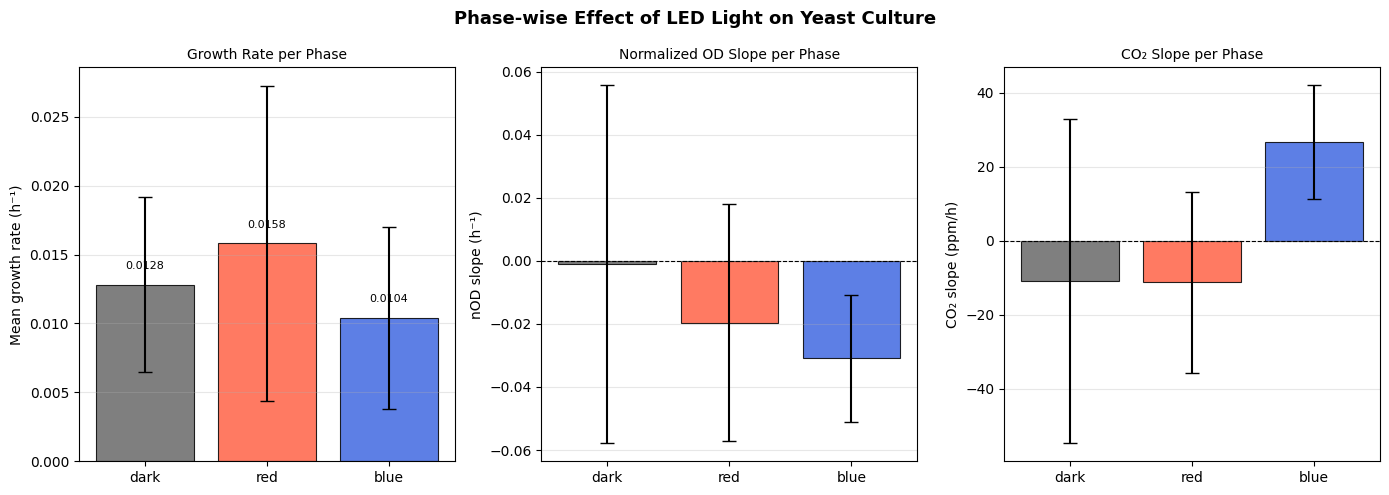

In [35]:
PHASE_COLORS = {'dark':'dimgrey','red':'tomato','blue':'royalblue','unknown':'white'}
 
# Bar charts for mean growth, nOD slope, CO2 slope
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Phase-wise Effect of LED Light on Yeast Culture', fontsize=13, fontweight='bold')
 
phase_order = ['dark','red','blue']
 
# Growth rate bar
ax = axes[0]
means = [growth_summary.get(p,{}).get('mean', np.nan) for p in phase_order]
errs  = [growth_summary.get(p,{}).get('std',  np.nan) for p in phase_order]
colors = [PHASE_COLORS[p] for p in phase_order]
bars = ax.bar(phase_order, means, yerr=errs, capsize=5,
              color=colors, edgecolor='black', linewidth=0.8, alpha=0.85)
ax.set_ylabel('Mean growth rate (h⁻¹)', fontsize=10)
ax.set_title('Growth Rate per Phase', fontsize=10)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, means):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)
 
# nOD slope bar
ax = axes[1]
if not nod_slopes_df.empty:
    nod_mean = nod_slopes_df.groupby('phase')['slope_per_h'].mean()
    nod_std  = nod_slopes_df.groupby('phase')['slope_per_h'].std().fillna(0)
    ph = [p for p in phase_order if p in nod_mean.index]
    ax.bar(ph, [nod_mean[p] for p in ph],
           yerr=[nod_std.get(p, 0) for p in ph],
           capsize=5, color=[PHASE_COLORS[p] for p in ph],
           edgecolor='black', linewidth=0.8, alpha=0.85)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_ylabel('nOD slope (h⁻¹)', fontsize=10)
ax.set_title('Normalized OD Slope per Phase', fontsize=10)
ax.grid(axis='y', alpha=0.3)
 
# CO2 slope bar
ax = axes[2]
if not co2_slopes_df.empty:
    co2_mean = co2_slopes_df.groupby('phase')['slope_ppm_per_h'].mean()
    co2_std  = co2_slopes_df.groupby('phase')['slope_ppm_per_h'].std().fillna(0)
    ph = [p for p in phase_order if p in co2_mean.index]
    ax.bar(ph, [co2_mean[p] for p in ph],
           yerr=[co2_std.get(p, 0) for p in ph],
           capsize=5, color=[PHASE_COLORS[p] for p in ph],
           edgecolor='black', linewidth=0.8, alpha=0.85)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_ylabel('CO₂ slope (ppm/h)', fontsize=10)
ax.set_title('CO₂ Slope per Phase', fontsize=10)
ax.grid(axis='y', alpha=0.3)
 
plt.tight_layout()


Variability

- Red has highest CV (0.72) — red light causes the most unstable growth, possibly because the mild stimulation interacts unpredictably with chemostat dilution
- Blue CV = 0.64, Dark CV = 0.50 — dark is the most stable as expected

Relative Effect (vs surrounding dark baseline)

- Red: +0.0019 h⁻¹ mean — slight positive effect across all red instances
- Blue: -0.0028 h⁻¹ mean — consistent negative effect across all blue instances

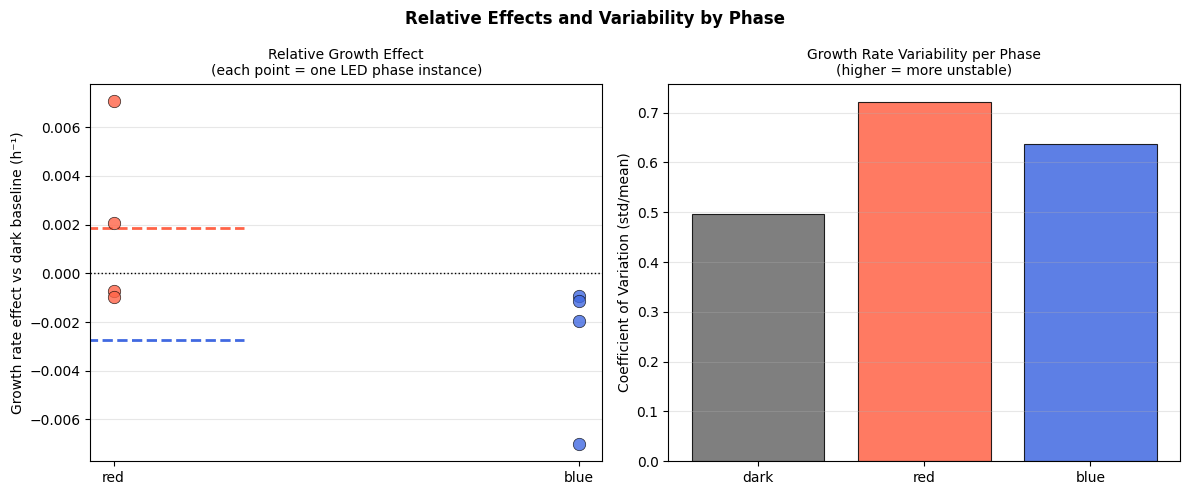

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Relative Effects and Variability by Phase', fontsize=12, fontweight='bold')
 
# Relative effect scatter
ax = axes[0]
if not rel_df.empty:
    for phase, color in [('red','tomato'),('blue','royalblue')]:
        sub = rel_df[rel_df['phase']==phase]
        ax.scatter([phase]*len(sub), sub['relative_effect'],
                   color=color, s=80, zorder=3, alpha=0.8, edgecolors='black', lw=0.5)
        ax.hlines(sub['relative_effect'].mean(), -0.3, 0.3,
                  transform=ax.get_yaxis_transform(), colors=color, lw=2, ls='--')
ax.axhline(0, color='black', lw=1, ls=':')
ax.set_ylabel('Growth rate effect vs dark baseline (h⁻¹)', fontsize=10)
ax.set_title('Relative Growth Effect\n(each point = one LED phase instance)', fontsize=10)
ax.grid(axis='y', alpha=0.3)
 
# Variability (CV)
ax = axes[1]
cv_data = growth.groupby('phase').apply(
    lambda g: g['rate'].std() / abs(g['rate'].mean()) if g['rate'].mean() != 0 else np.nan
).reindex(phase_order)
ax.bar(phase_order, cv_data.values,
       color=[PHASE_COLORS[p] for p in phase_order],
       edgecolor='black', linewidth=0.8, alpha=0.85)
ax.set_ylabel('Coefficient of Variation (std/mean)', fontsize=10)
ax.set_title('Growth Rate Variability per Phase\n(higher = more unstable)', fontsize=10)
ax.grid(axis='y', alpha=0.3)
 
plt.tight_layout()